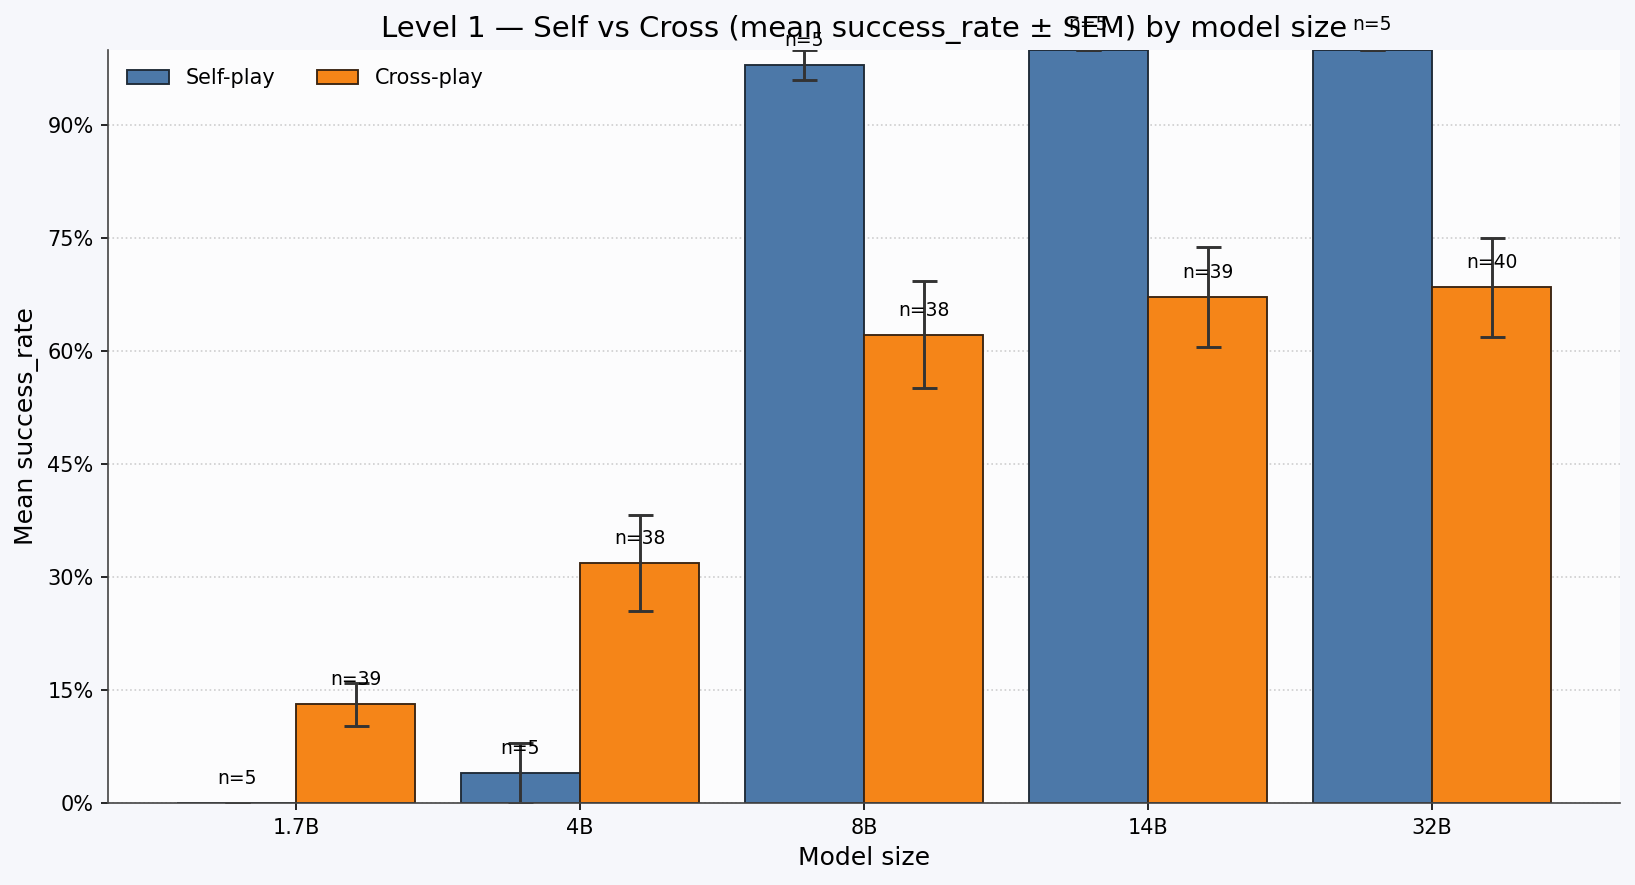

Saved -> ./plots/level_1__self_vs_cross_by_size.png


/var/folders/zs/vqkr9f1s7k7957sf_gd0vw940000gn/T/ipykernel_80495/1207081389.py:257: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_cycle = plt.cm.get_cmap("tab10", max(10, len(chef_sizes)))


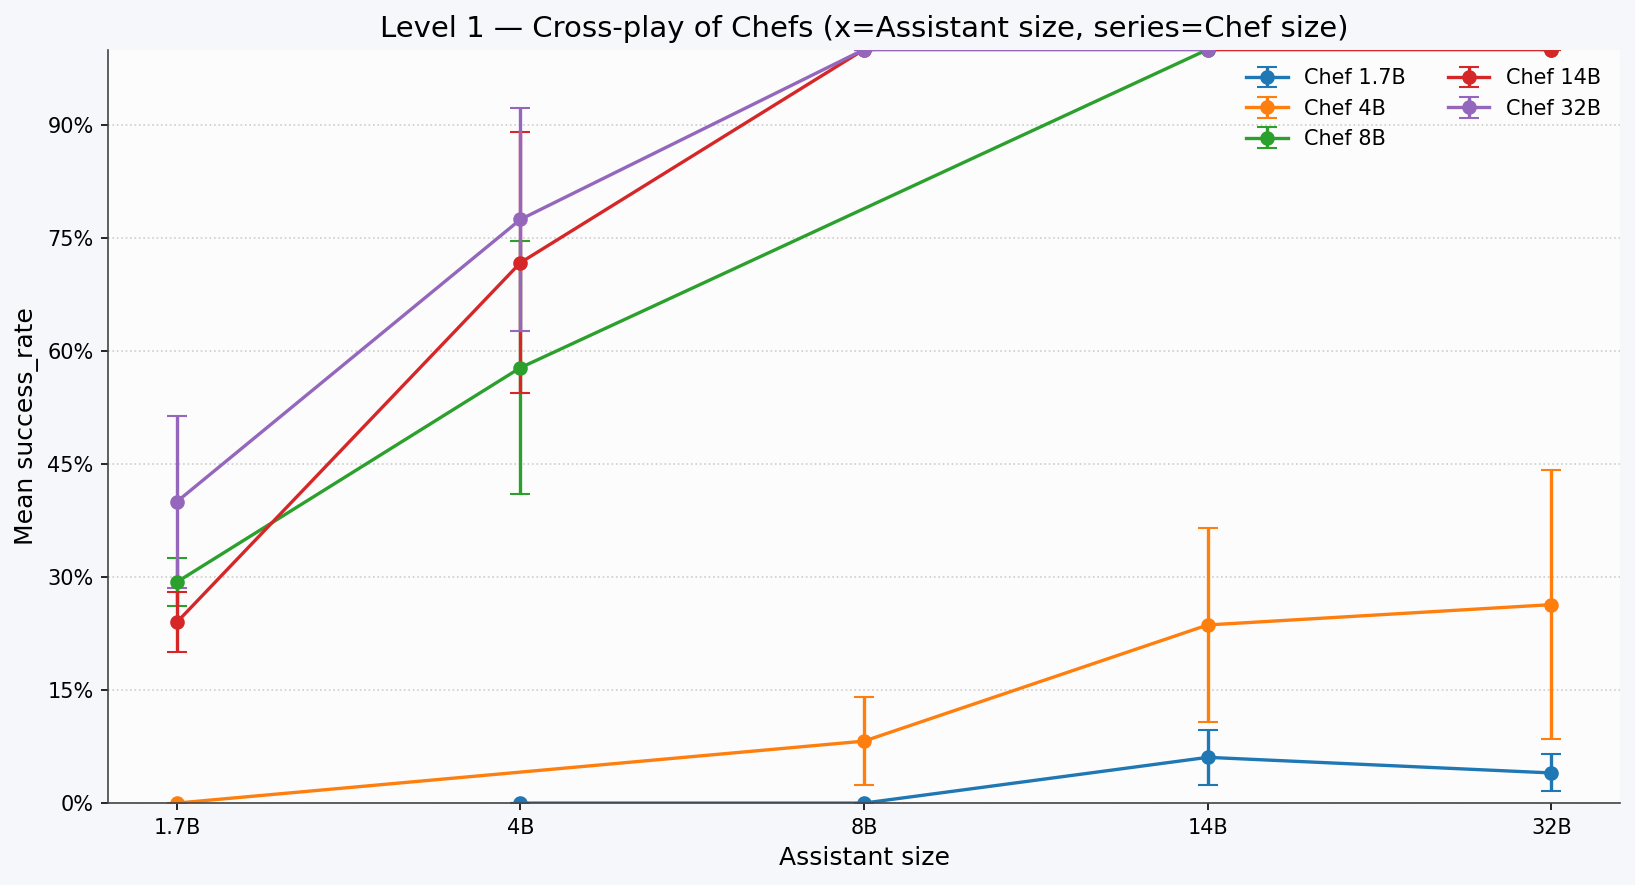

Saved -> ./plots/level_1__cross_play_of_chefs.png


/var/folders/zs/vqkr9f1s7k7957sf_gd0vw940000gn/T/ipykernel_80495/1207081389.py:293: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_cycle = plt.cm.get_cmap("tab10", max(10, len(assistant_sizes)))


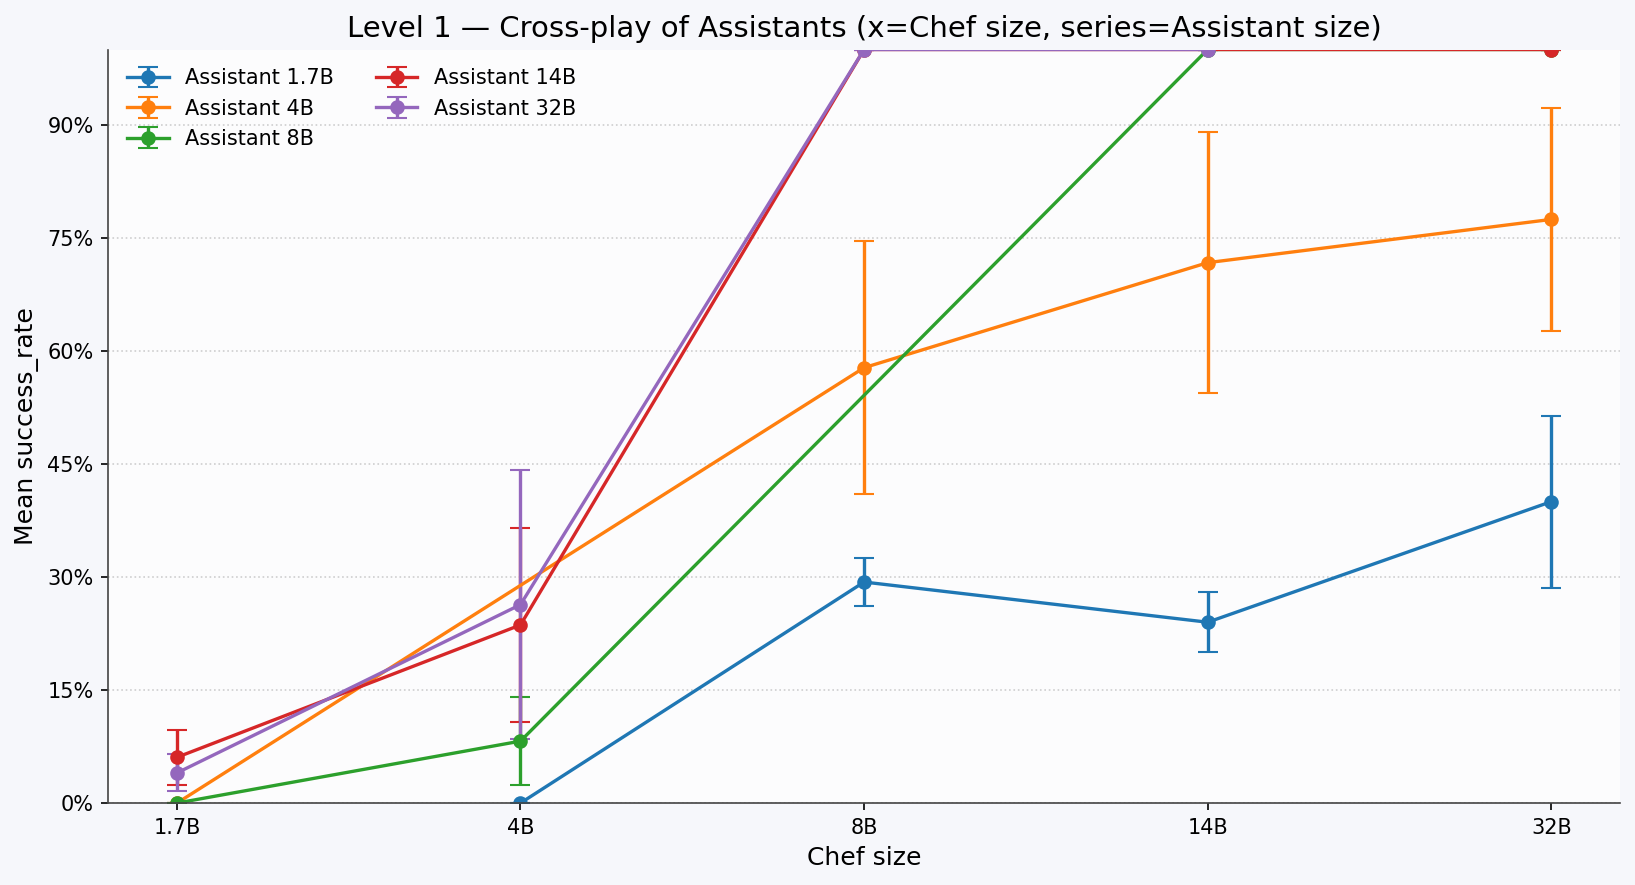

Saved -> ./plots/level_1__cross_play_of_assistants.png


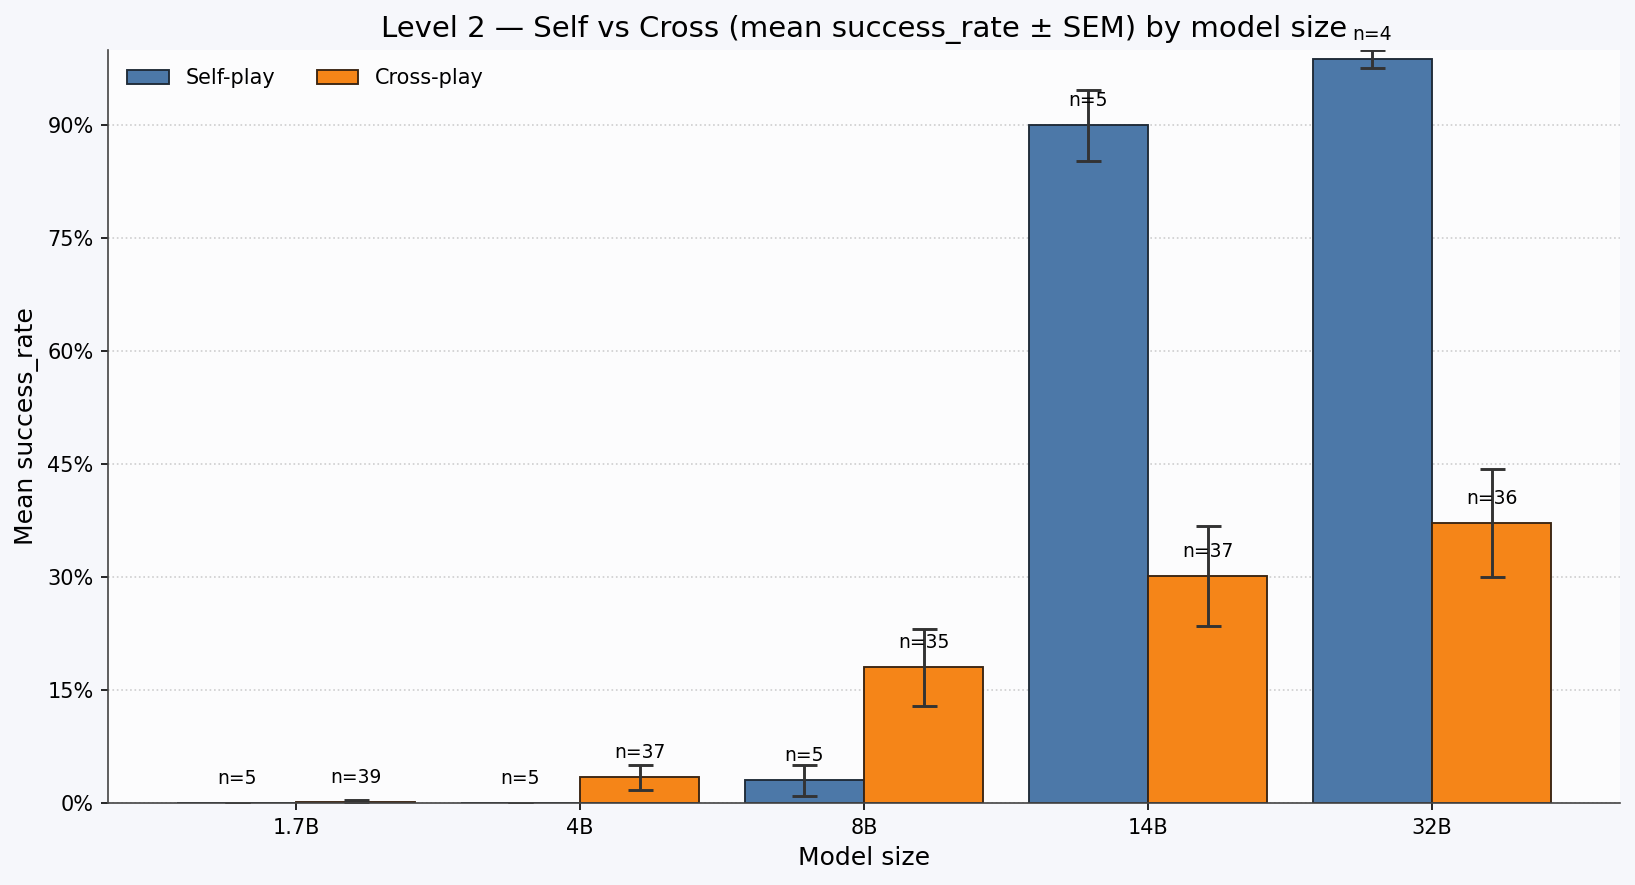

Saved -> ./plots/level_2__self_vs_cross_by_size.png


/var/folders/zs/vqkr9f1s7k7957sf_gd0vw940000gn/T/ipykernel_80495/1207081389.py:257: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_cycle = plt.cm.get_cmap("tab10", max(10, len(chef_sizes)))


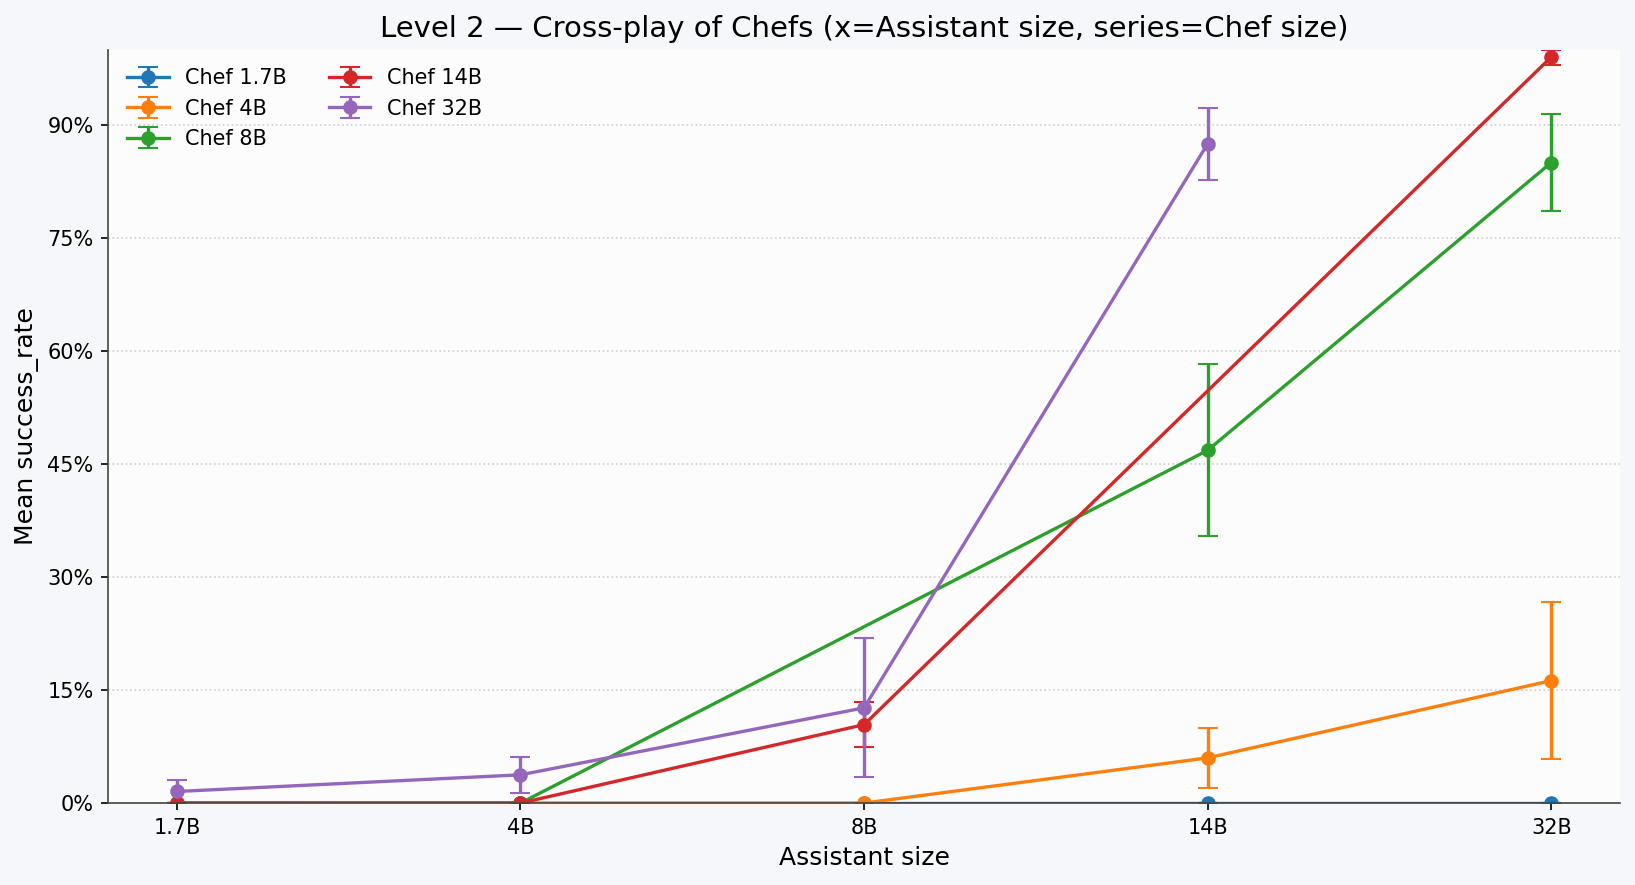

Saved -> ./plots/level_2__cross_play_of_chefs.png


/var/folders/zs/vqkr9f1s7k7957sf_gd0vw940000gn/T/ipykernel_80495/1207081389.py:293: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_cycle = plt.cm.get_cmap("tab10", max(10, len(assistant_sizes)))


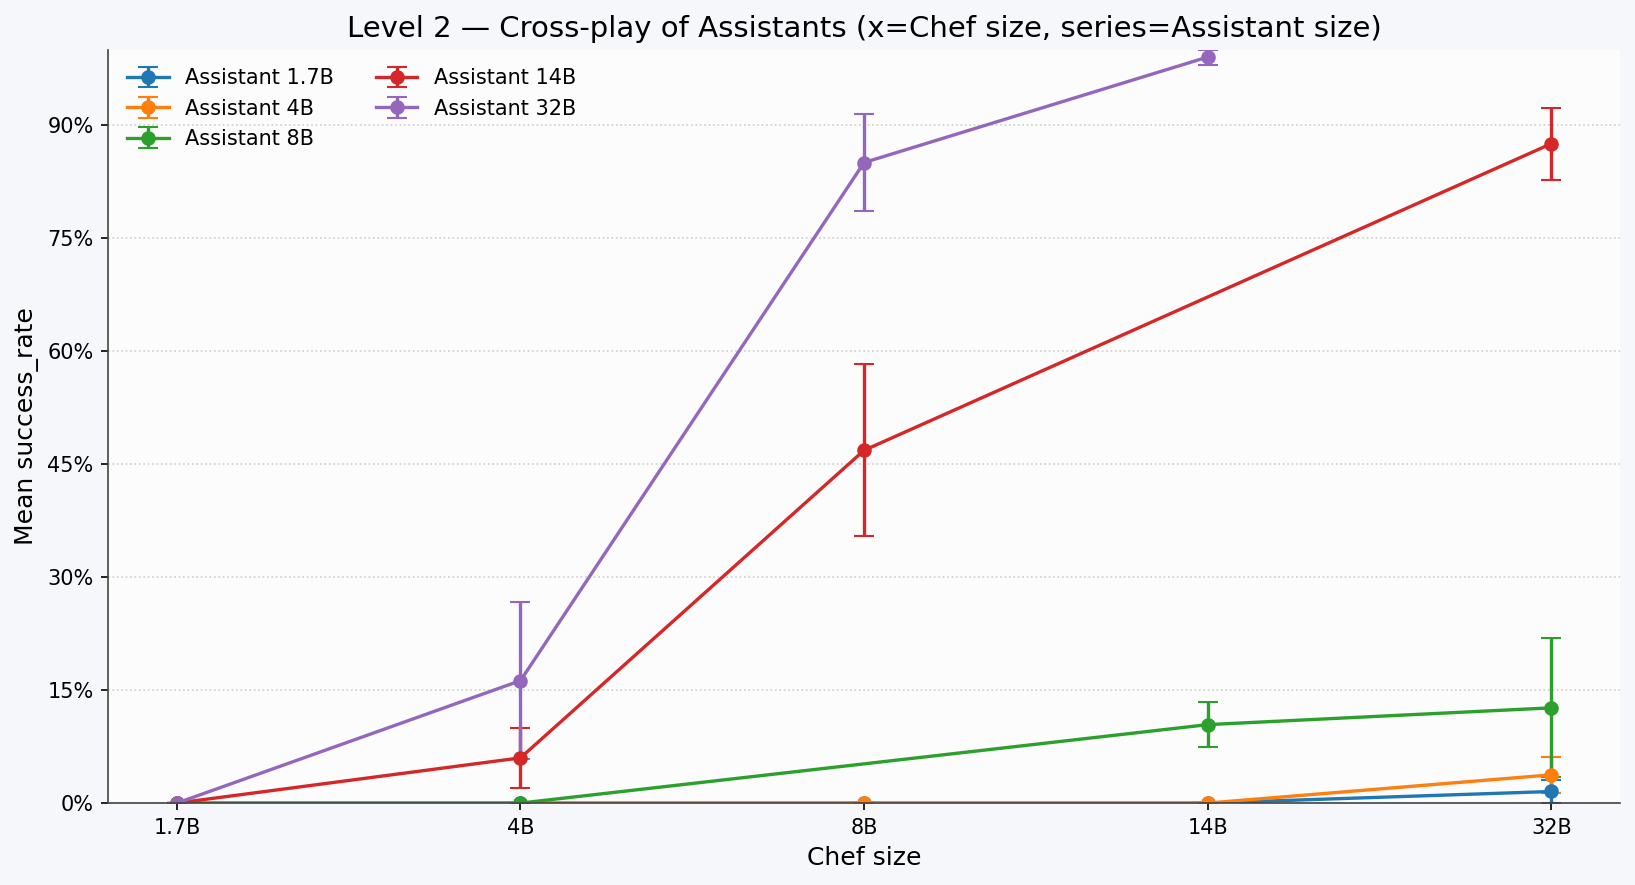

Saved -> ./plots/level_2__cross_play_of_assistants.png


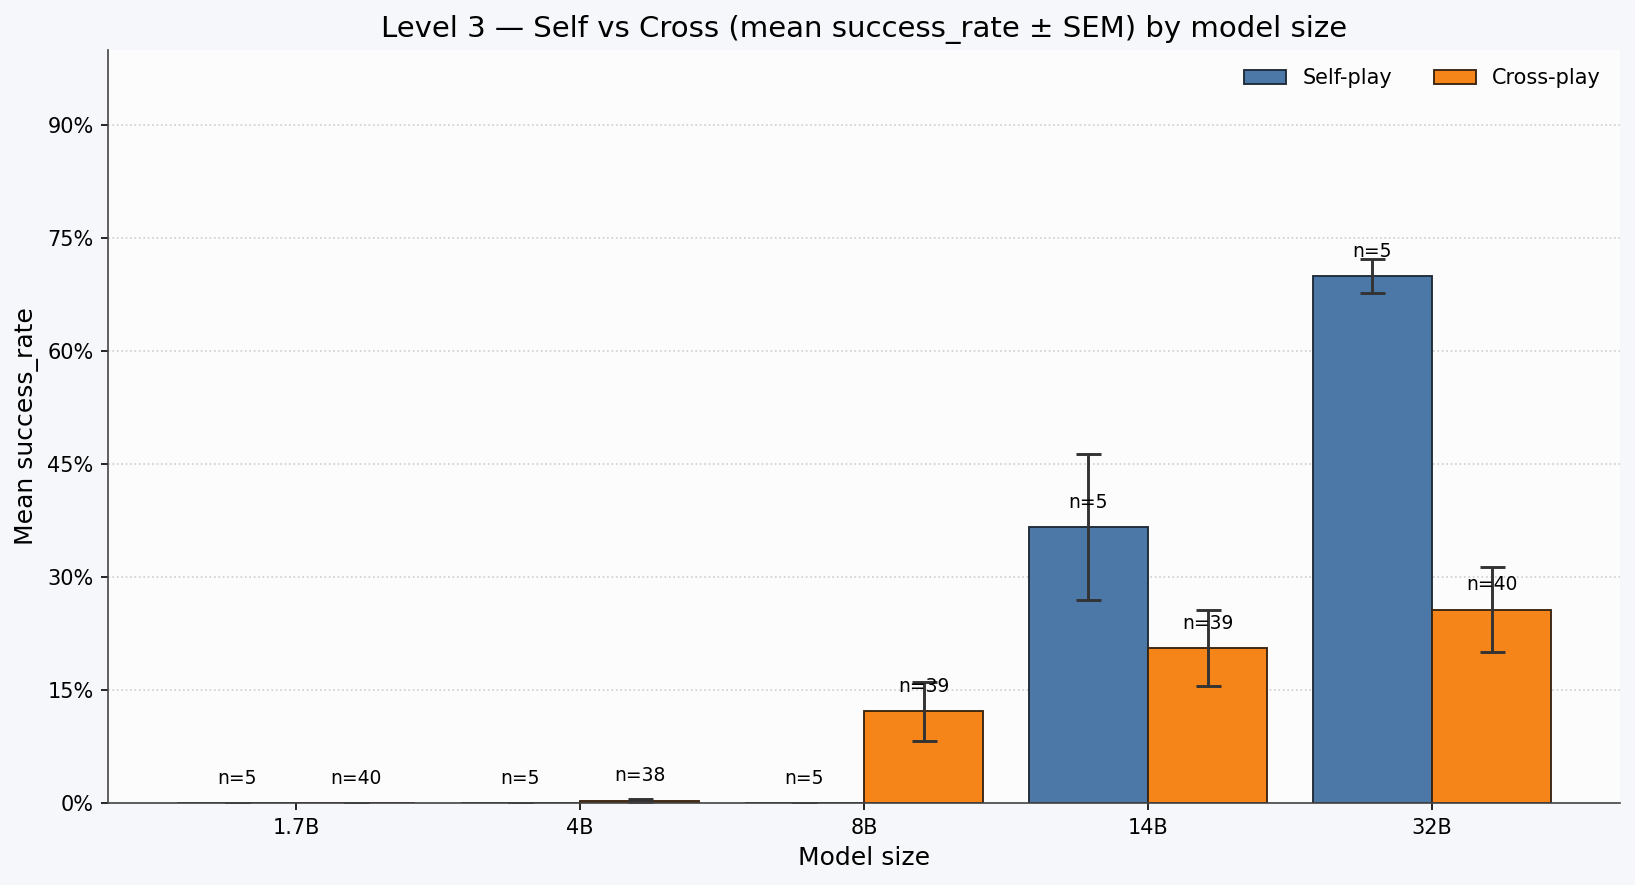

Saved -> ./plots/level_3__self_vs_cross_by_size.png


/var/folders/zs/vqkr9f1s7k7957sf_gd0vw940000gn/T/ipykernel_80495/1207081389.py:257: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_cycle = plt.cm.get_cmap("tab10", max(10, len(chef_sizes)))


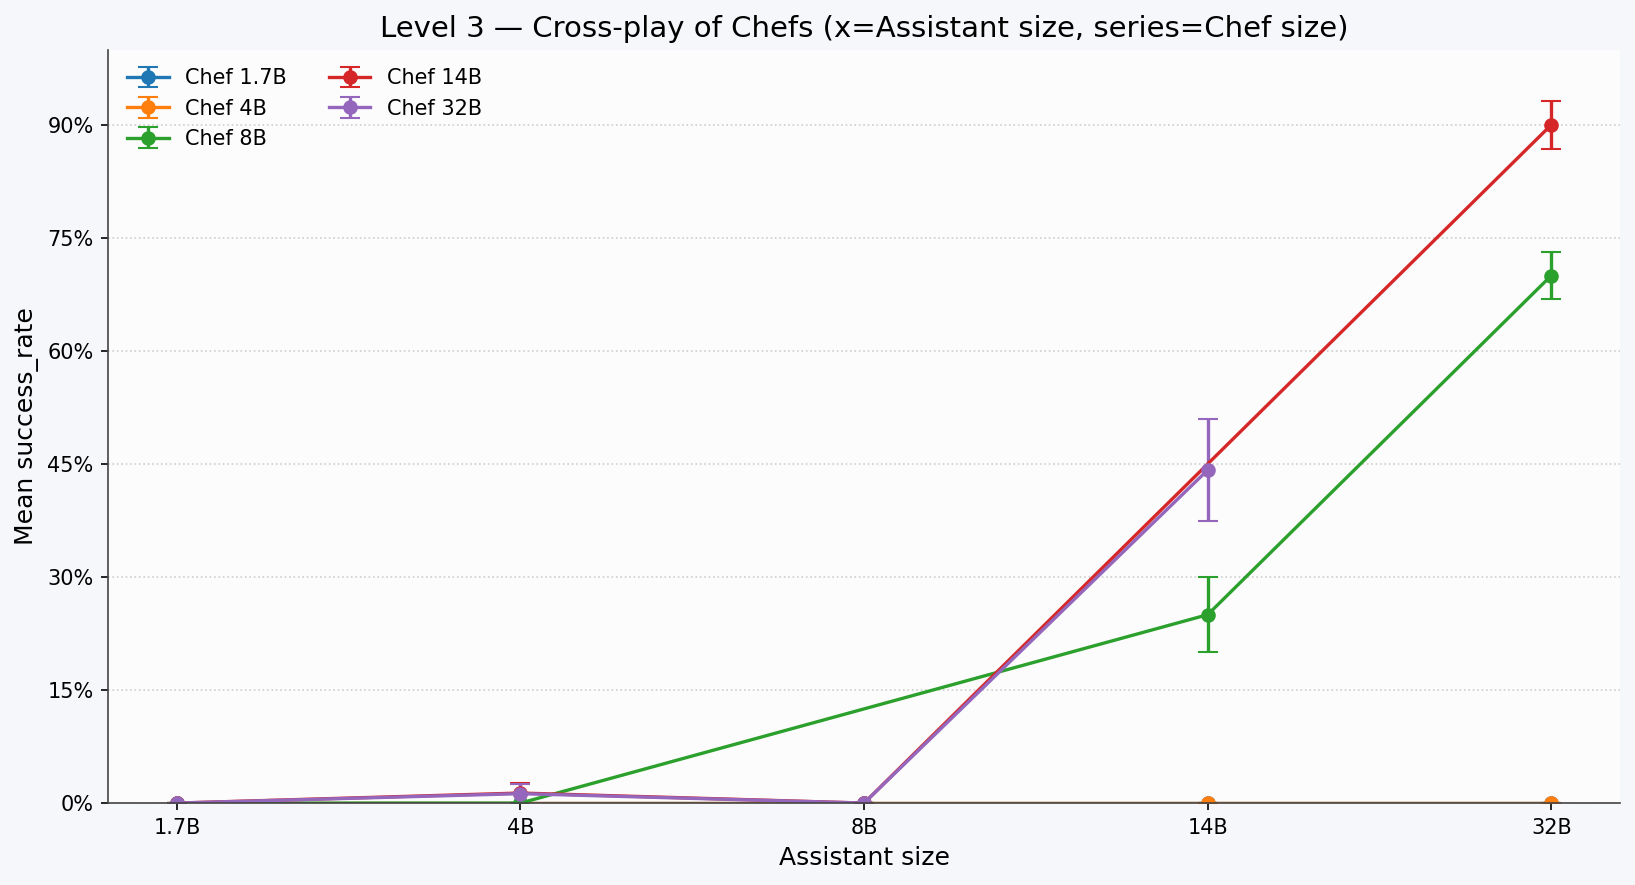

Saved -> ./plots/level_3__cross_play_of_chefs.png


/var/folders/zs/vqkr9f1s7k7957sf_gd0vw940000gn/T/ipykernel_80495/1207081389.py:293: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_cycle = plt.cm.get_cmap("tab10", max(10, len(assistant_sizes)))


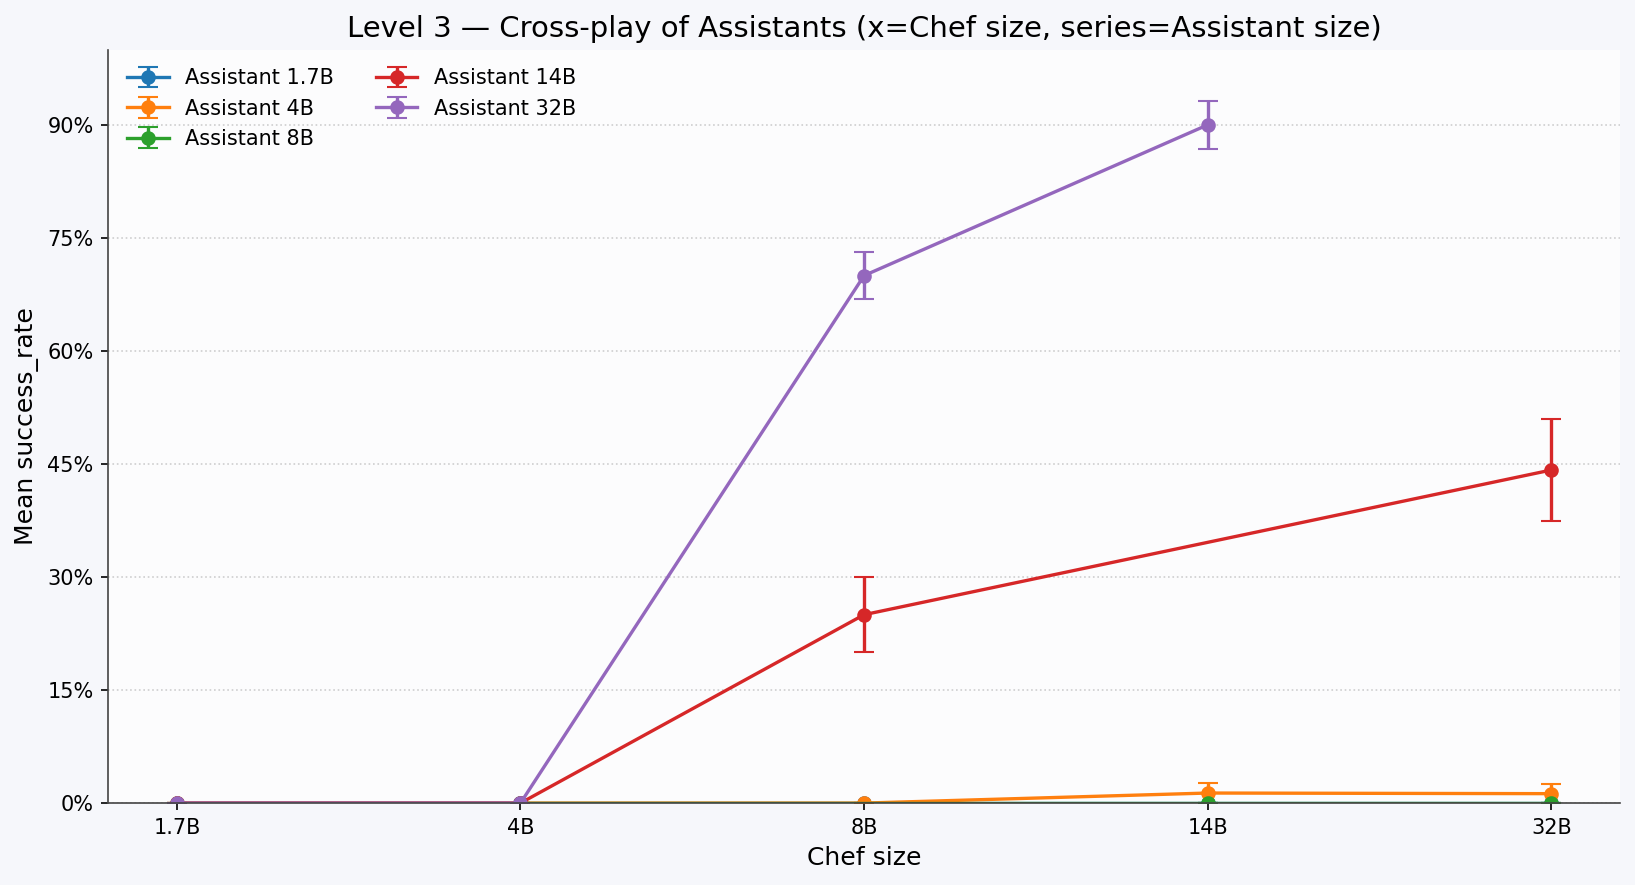

Saved -> ./plots/level_3__cross_play_of_assistants.png


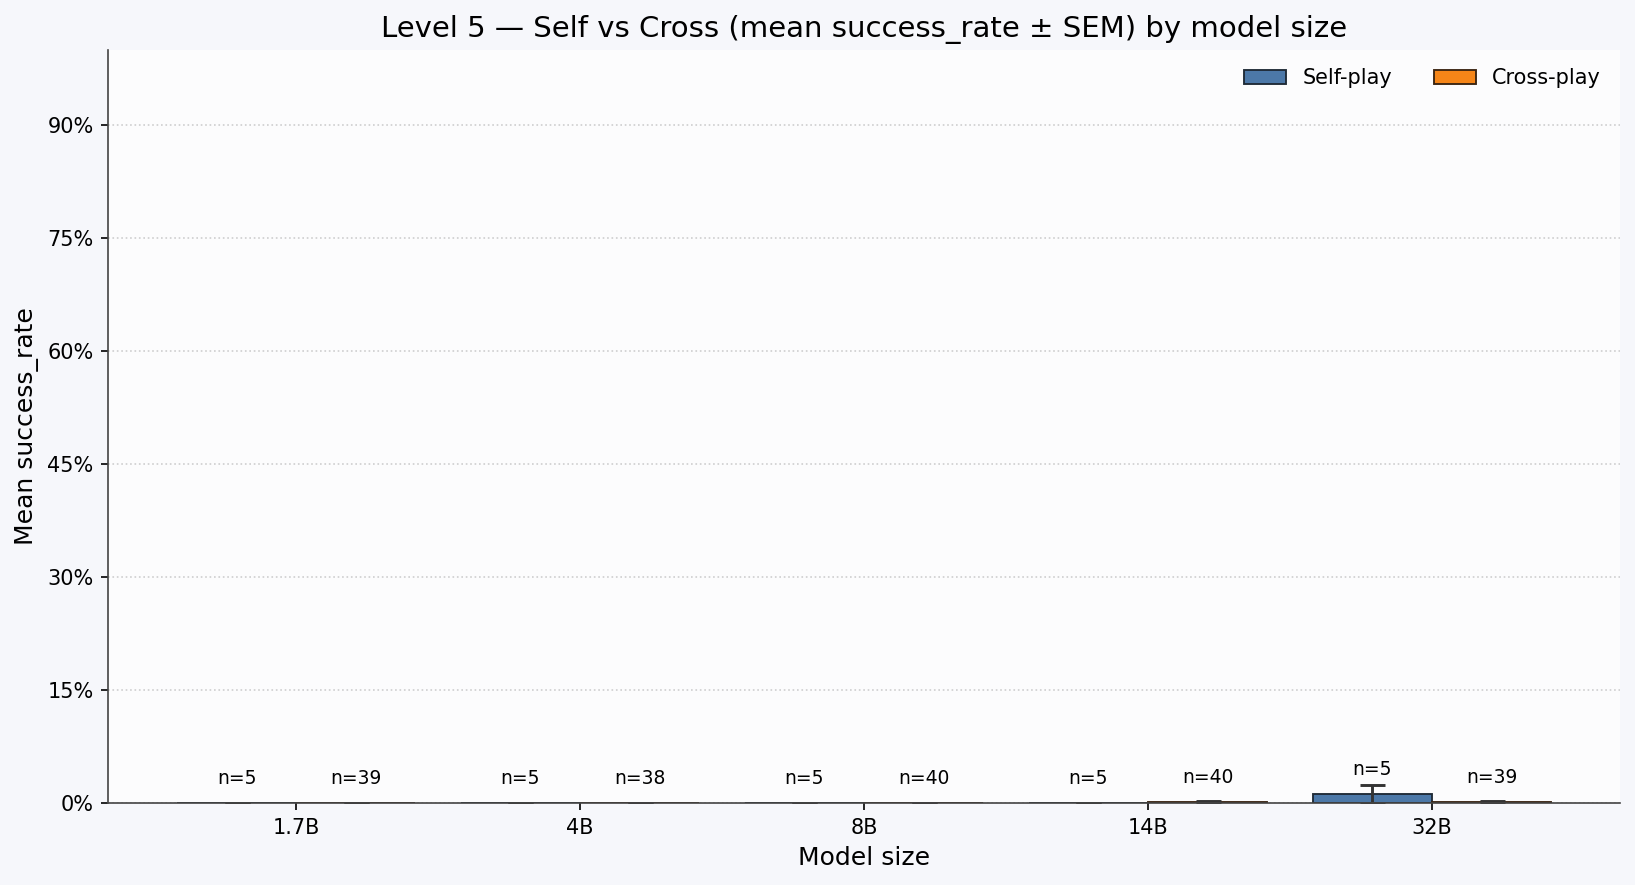

Saved -> ./plots/level_5__self_vs_cross_by_size.png


/var/folders/zs/vqkr9f1s7k7957sf_gd0vw940000gn/T/ipykernel_80495/1207081389.py:257: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_cycle = plt.cm.get_cmap("tab10", max(10, len(chef_sizes)))


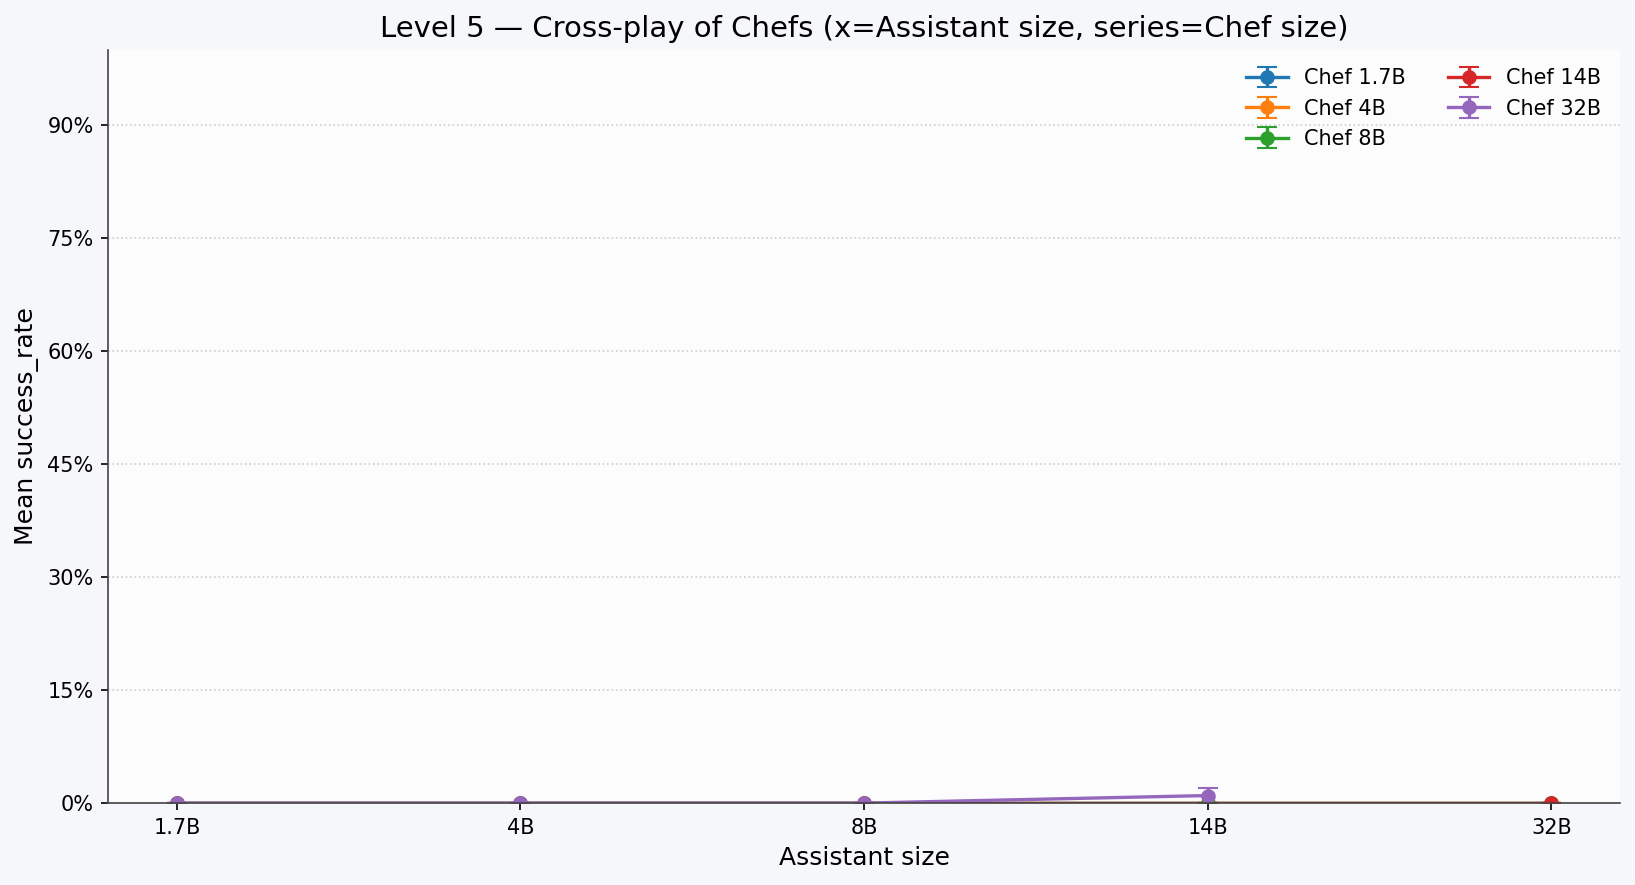

Saved -> ./plots/level_5__cross_play_of_chefs.png


/var/folders/zs/vqkr9f1s7k7957sf_gd0vw940000gn/T/ipykernel_80495/1207081389.py:293: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_cycle = plt.cm.get_cmap("tab10", max(10, len(assistant_sizes)))


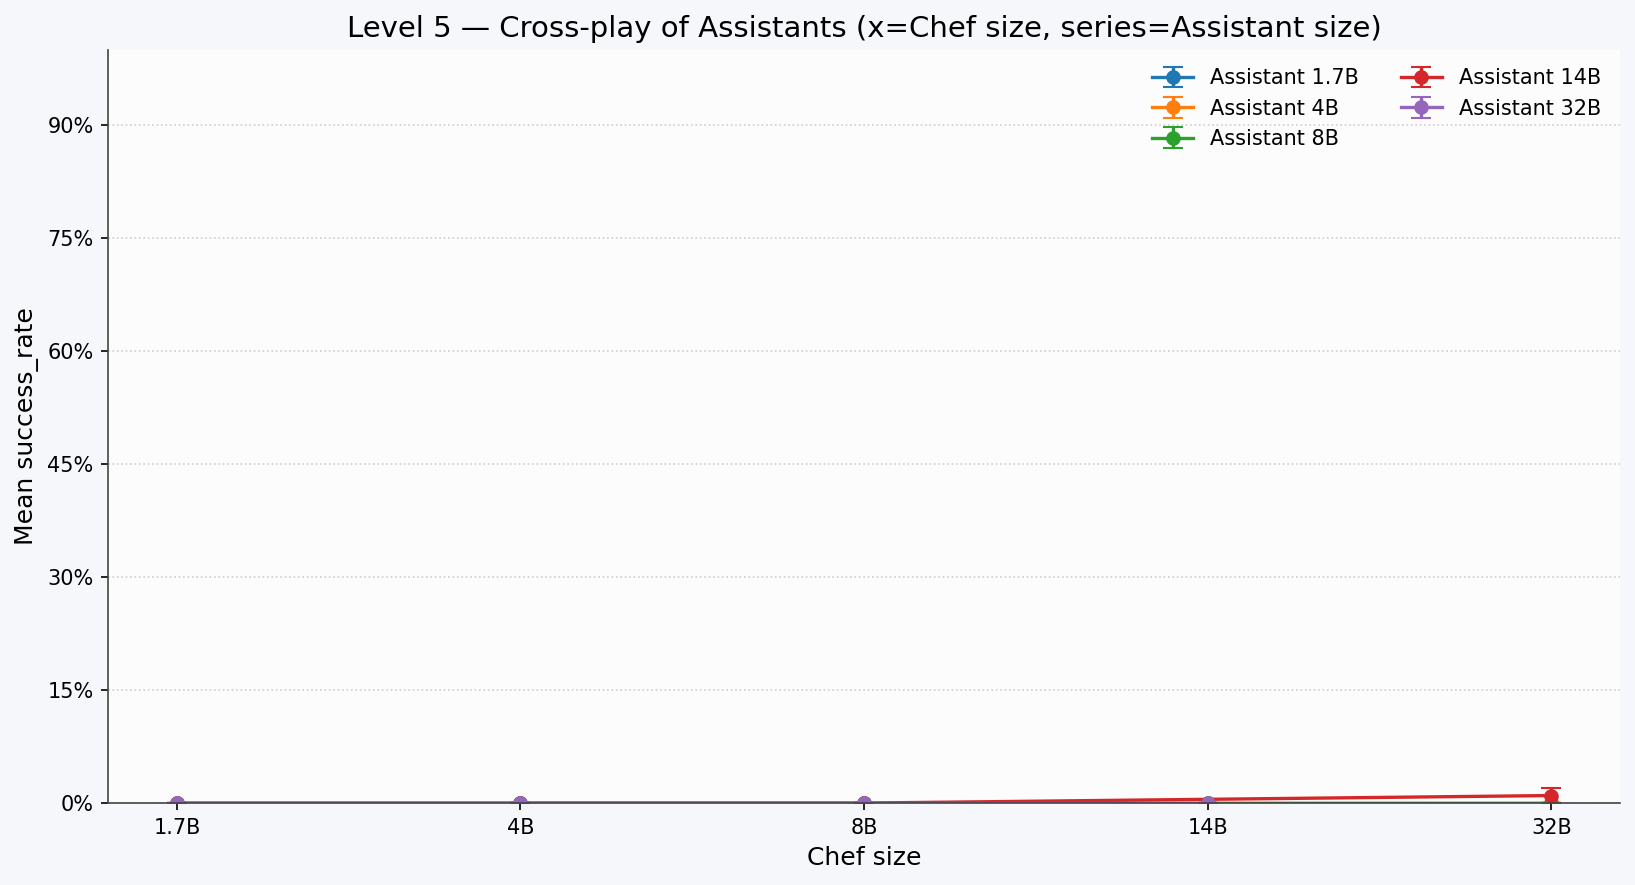

Saved -> ./plots/level_5__cross_play_of_assistants.png


In [2]:
# NumPy + matplotlib (no pandas)
# Per-level charts:
#   (1) Self vs Cross — mean success_rate ± SEM by model size (grouped bars)
#   (2) Cross-play of Chefs — x=Assistant size, one series per Chef size (agent_0)
#   (3) Cross-play of Assistants — x=Chef size, one series per Assistant size (agent_1)
#
# Role mapping (agreed):
#   agent_0 = Chef (first model in 'model' string)
#   agent_1 = Assistant (second model in 'model' string)

import os
import numpy as np
import csv
import re
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
from collections import defaultdict

# ---------- Config ----------
INPUT_CANDIDATES = ["statistics_data_final-data.csv"]
OUT_DIR = "./plots"
VERBOSE_SUMMARY = True  # set False to suppress console summaries
SHOW_IN_NOTEBOOK = True # show figures inline (and also save them)

# Distinct, readable base colors for self/cross; series will use a palette.
COLORS = {"self": "#4C78A8", "cross": "#F58518"}  # blue / orange

# Style tweaks for a clean, modern look
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 200,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.edgecolor": "#444444",
    "axes.linewidth": 0.8,
})

# ---------- Helpers ----------
def find_path(cands):
    for p in cands:
        if os.path.exists(p):
            return p
    raise FileNotFoundError(f"Could not find CSV at any of: {cands}")

def parse_pair(model_str):
    # Expect pattern like "Vendor_ModelA-Vsize_Vendor_ModelB-Vsize"
    parts = model_str.split("_")
    if len(parts) >= 4:
        a = parts[0] + "_" + parts[1]  # agent_0 (Chef)
        b = parts[2] + "_" + parts[3]  # agent_1 (Assistant)
    else:
        mid = len(parts) // 2
        a = "_".join(parts[:mid])
        b = "_".join(parts[mid:])
    return a, b

_size_regex = re.compile(r'(\d+(?:\.\d+)?)\s*[Bb]\b')

def extract_size(label):
    # Try last hyphen token first (e.g., "Qwen3-32B" -> "32B")
    toks = label.split("-")
    for tok in reversed(toks):
        tok = tok.strip()
        if tok and (tok[-1] in "Bb"):
            m = _size_regex.match(tok)
            if m:
                num = m.group(1)
                return f"{num}B"
    # Fallback: search anywhere
    m = _size_regex.search(label)
    if m:
        return f"{m.group(1)}B"
    return None

def sem(x):
    x = np.asarray(x, dtype=float)
    n = x.size
    if n <= 1:
        return float("nan")
    return float(np.std(x, ddof=1) / np.sqrt(n))

def size_key(sz):
    try:
        return float(sz[:-1])
    except Exception:
        return float("inf")

def polish_axes(ax):
    ax.grid(True, axis="y", linestyle=":", linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)
    ax.set_facecolor("#FCFCFD")
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

def format_as_percent_if_applicable(ax, ymax_est):
    # If success_rate is in [0,1], swap to % ticks.
    if np.isfinite(ymax_est) and ymax_est <= 1.05:
        ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v*100:.0f}%"))
        ax.set_ylim(0, max(1.0, ymax_est))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=8))

def sanitize_token(s):
    return re.sub(r'[^A-Za-z0-9._-]+', '_', str(s))

def show_and_save(fig, path):
    # display first (for notebooks), then save, then close
    if SHOW_IN_NOTEBOOK:
        try:
            from IPython.display import display
            display(fig)
        except Exception:
            try:
                plt.show()
            except Exception:
                pass
    fig.savefig(path)
    plt.close(fig)
    print("Saved ->", path)

# ---------- Load ----------
path = find_path(INPUT_CANDIDATES)

# Aggregates
# buckets_by_size[(level, size, type)] -> list[success_rate], type in {"self","cross"}  (size = generic size bucket)
buckets_by_size = defaultdict(list)

# Cross decomposition matrices (role aware)
# cross_matrix[level][chef_size][assistant_size] -> list[success_rate]
cross_matrix = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

# Track which sizes appear as chef vs assistant, per level
chef_sizes_by_level = defaultdict(set)
assistant_sizes_by_level = defaultdict(set)

levels_seen = set()
sizes_seen_by_level = defaultdict(set)  # for combined self vs cross chart

with open(path, newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        try:
            sr = float(row["success_rate"])
            model_str = row["model"]
            level = row["level"]
        except (KeyError, ValueError):
            continue
        if not level:
            continue

        a, b = parse_pair(model_str)
        sa = extract_size(a)  # agent_0 (Chef)
        sb = extract_size(b)  # agent_1 (Assistant)
        if sa is None or sb is None:
            continue

        levels_seen.add(level)
        sizes_seen_by_level[level].update([sa, sb])

        # Self vs Cross (size-agnostic of role)
        if sa == sb:
            buckets_by_size[(level, sa, "self")].append(sr)
        else:
            # count cross for both sizes in the size-based view
            buckets_by_size[(level, sa, "cross")].append(sr)
            buckets_by_size[(level, sb, "cross")].append(sr)

            # role-aware cross matrices
            cross_matrix[level][sa][sb].append(sr)  # Chef=sa, Assistant=sb
            chef_sizes_by_level[level].add(sa)
            assistant_sizes_by_level[level].add(sb)

# Sort levels (numeric if possible, else lexical)
def level_key(x):
    try:
        return (0, float(x))
    except Exception:
        return (1, str(x))
levels_sorted = sorted(levels_seen, key=level_key)

# ---------- Per-level charts ----------
os.makedirs(OUT_DIR, exist_ok=True)
error_kw_common = dict(ecolor="#333333", linewidth=1.4, capsize=6, capthick=1.4)

for lvl in levels_sorted:
    # ========= (1) Combined Self vs Cross by size (grouped bars) =========
    sizes_sorted = sorted(sizes_seen_by_level[lvl], key=size_key)

    # assemble stats
    means_self_all, sems_self_all, n_self_all = [], [], []
    means_cross_all, sems_cross_all, n_cross_all = [], [], []
    for sz in sizes_sorted:
        xs = np.array(buckets_by_size.get((lvl, sz, "self"), []), dtype=float)
        xc = np.array(buckets_by_size.get((lvl, sz, "cross"), []), dtype=float)

        n_s = int(xs.size); n_c = int(xc.size)
        m_s = float(np.mean(xs)) if n_s else float("nan")
        m_c = float(np.mean(xc)) if n_c else float("nan")
        s_s = sem(xs) if n_s else float("nan")
        s_c = sem(xc) if n_c else float("nan")

        means_self_all.append(m_s); sems_self_all.append(s_s); n_self_all.append(n_s)
        means_cross_all.append(m_c); sems_cross_all.append(s_c); n_cross_all.append(n_c)

    x = np.arange(len(sizes_sorted))
    width = 0.42
    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor("#F6F7FB")

    # ymax estimate
    a = np.nan_to_num(np.array(means_self_all),  nan=0.0) + np.nan_to_num(np.array(sems_self_all),  nan=0.0)
    b = np.nan_to_num(np.array(means_cross_all), nan=0.0) + np.nan_to_num(np.array(sems_cross_all), nan=0.0)
    ymax_est = float(max(np.max(a) if a.size else 0.0, np.max(b) if b.size else 0.0))

    b1 = ax.bar(x - width/2, means_self_all,  width, yerr=sems_self_all,  label="Self-play",
                color=COLORS["self"],  edgecolor="#1f2a36", linewidth=0.9, error_kw=error_kw_common)
    b2 = ax.bar(x + width/2, means_cross_all, width, yerr=sems_cross_all, label="Cross-play",
                color=COLORS["cross"], edgecolor="#3a2412", linewidth=0.9, error_kw=error_kw_common)

    ax.set_xticks(x, sizes_sorted)
    ax.set_xlabel("Model size")
    ax.set_ylabel("Mean success_rate")
    ax.set_title(f"Level {lvl} — Self vs Cross (mean success_rate ± SEM) by model size")
    polish_axes(ax)
    format_as_percent_if_applicable(ax, ymax_est)
    ax.legend(frameon=False, ncol=2)

    # annotate sample sizes above bars
    ymin, ymax = ax.get_ylim(); yrange = ymax - ymin
    for rect, n in zip(b1, n_self_all):
        h = rect.get_height()
        if np.isfinite(h):
            ax.text(rect.get_x()+rect.get_width()/2, h + 0.02*yrange, f"n={n}", ha="center", va="bottom", fontsize=9)
    for rect, n in zip(b2, n_cross_all):
        h = rect.get_height()
        if np.isfinite(h):
            ax.text(rect.get_x()+rect.get_width()/2, h + 0.02*yrange, f"n={n}", ha="center", va="bottom", fontsize=9)

    combined_png = os.path.join(OUT_DIR, f"level_{sanitize_token(lvl)}__self_vs_cross_by_size.png")
    fig.tight_layout()
    show_and_save(fig, combined_png)

    # Skip cross decomposition if no cross data at this level
    if lvl not in cross_matrix or len(cross_matrix[lvl]) == 0:
        continue

    # ========= (2) Cross-play of Chefs (x = Assistant size; series = Chef size) =========
    chef_sizes = sorted(chef_sizes_by_level[lvl], key=size_key)
    assistant_sizes = sorted(assistant_sizes_by_level[lvl], key=size_key)

    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor("#F6F7FB")

    color_cycle = plt.cm.get_cmap("tab10", max(10, len(chef_sizes)))

    ymax_est = 0.0
    for i, csz in enumerate(chef_sizes):
        # collect points where Chef=csz; assistants vary
        xs_idx, ys_mean, ys_sem = [], [], []
        for j, asz in enumerate(assistant_sizes):
            vals = np.array(cross_matrix[lvl][csz].get(asz, []), dtype=float)
            if vals.size == 0:
                continue  # no datum for this (chef, assistant)
            xs_idx.append(j)
            m = float(np.mean(vals)); s = sem(vals)
            ys_mean.append(m); ys_sem.append(s)
            ymax_est = max(ymax_est, m + (s if np.isfinite(s) else 0.0))

        if len(xs_idx) == 0:
            continue
        ax.errorbar(xs_idx, ys_mean, yerr=ys_sem, fmt='-o', linewidth=1.6, capsize=5,
                    label=f"Chef {csz}", color=color_cycle(i))

    ax.set_xticks(np.arange(len(assistant_sizes)), assistant_sizes)
    ax.set_xlabel("Assistant size")
    ax.set_ylabel("Mean success_rate")
    ax.set_title(f"Level {lvl} — Cross-play of Chefs (x=Assistant size, series=Chef size)")
    polish_axes(ax)
    format_as_percent_if_applicable(ax, ymax_est if np.isfinite(ymax_est) else np.nan)
    ax.legend(frameon=False, ncol=2)

    chefs_png = os.path.join(OUT_DIR, f"level_{sanitize_token(lvl)}__cross_play_of_chefs.png")
    fig.tight_layout()
    show_and_save(fig, chefs_png)

    # ========= (3) Cross-play of Assistants (x = Chef size; series = Assistant size) =========
    fig, ax = plt.subplots(figsize=(11, 6))
    fig.patch.set_facecolor("#F6F7FB")

    color_cycle = plt.cm.get_cmap("tab10", max(10, len(assistant_sizes)))
    ymax_est = 0.0
    for i, asz in enumerate(assistant_sizes):
        xs_idx, ys_mean, ys_sem = [], [], []
        for j, csz in enumerate(chef_sizes):
            vals = np.array(cross_matrix[lvl][csz].get(asz, []), dtype=float)
            if vals.size == 0:
                continue
            xs_idx.append(j)
            m = float(np.mean(vals)); s = sem(vals)
            ys_mean.append(m); ys_sem.append(s)
            ymax_est = max(ymax_est, m + (s if np.isfinite(s) else 0.0))

        if len(xs_idx) == 0:
            continue
        ax.errorbar(xs_idx, ys_mean, yerr=ys_sem, fmt='-o', linewidth=1.6, capsize=5,
                    label=f"Assistant {asz}", color=color_cycle(i))

    ax.set_xticks(np.arange(len(chef_sizes)), chef_sizes)
    ax.set_xlabel("Chef size")
    ax.set_ylabel("Mean success_rate")
    ax.set_title(f"Level {lvl} — Cross-play of Assistants (x=Chef size, series=Assistant size)")
    polish_axes(ax)
    format_as_percent_if_applicable(ax, ymax_est if np.isfinite(ymax_est) else np.nan)
    ax.legend(frameon=False, ncol=2)

    assistants_png = os.path.join(OUT_DIR, f"level_{sanitize_token(lvl)}__cross_play_of_assistants.png")
    fig.tight_layout()
    show_and_save(fig, assistants_png)
